# AIoT Project

This notebook is the entry point for the analysis pipeline. It assumes the PAMAP2 dataset has already been parsed and ingested into MongoDB by `aiot_dataset_creation_sample.ipynb` — every cell below should fetch its inputs from the MongoDB collection, **not** from the raw `.dat` files.

In [1]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# db
import pymongo

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca

%load_ext autoreload
%autoreload 2

Start time of execution

In [2]:
time_start = time()

## Load configuration

In [3]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path, "r", encoding="utf-8") as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [4]:
client = pymongo.MongoClient(config["client"])

In [5]:
db = client[config["db"]]
coll = db[config["col"]]

In [6]:
found_labels = coll.distinct("activity_label")
print("Activities in DB:", found_labels)

Activities in DB: ['Nordic walking', 'ascending stairs', 'cycling', 'descending stairs', 'ironing', 'lying', 'rope jumping', 'running', 'sitting', 'standing', 'unknown', 'vacuum cleaning', 'walking']


## Load data

Fetch the documents that correspond to the **sensor configuration you are evaluating**. Start with the hand/wrist IMU in the AccGyr configuration (the default), e.g.:

```python
query = {"imu_location": "hand", "sensor": "AccGyr"}
documents = list(coll.find(query))
```

Carry the `subject` field through every transformation (windowing, filtering, feature extraction) — you will need it for the **subject-disjoint** train/test split below.

When you later expand to chest/ankle IMUs, change the query and re-run the pipeline so you can compare the per-configuration results in your report.

In [7]:
query = {"split":"Protocol", "imu_location": "hand", "sensor": "AccGyr"}
documents = list(coll.find(query))


In [8]:
df_segments = pd.DataFrame(documents)

print(df_segments.columns)

Index(['_id', 'data', 'activity_id', 'activity_label', 'subject', 'split',
       'imu_location', 'sensor', 'sr', 'datetime'],
      dtype='str')


## Explore the nature of the data

Suggested exploratory plots for the PAMAP2 instances you loaded:

* Total recording time per activity (sum of segment lengths in seconds, grouped by `activity_label`).
* A time-domain plot of one segment per activity, so you can see the signal shape of each class.
* The distribution of segment counts per `(subject, activity_label)` pair — this exposes the class imbalance you will need to address.

C:\Users\user\AppData\Local\Temp\ipykernel_53720\4078532114.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=activity_time.values, y=activity_time.index, palette='viridis')


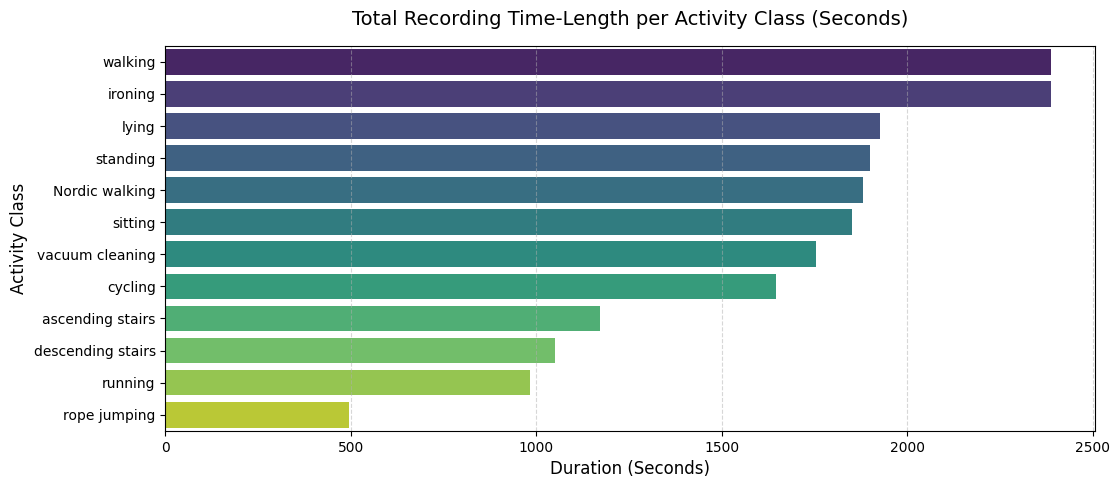

In [9]:
df_segments['num_samples'] = df_segments['data'].apply(lambda x: len(x['acc_x']))
df_segments['duration_seconds'] = df_segments['num_samples'] / 100.0

activity_time = df_segments.groupby('activity_label')['duration_seconds'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=activity_time.values, y=activity_time.index, palette='viridis')
plt.title('Total Recording Time-Length per Activity Class (Seconds)', fontsize=14, pad=15)
plt.xlabel('Duration (Seconds)', fontsize=12)
plt.ylabel('Activity Class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()



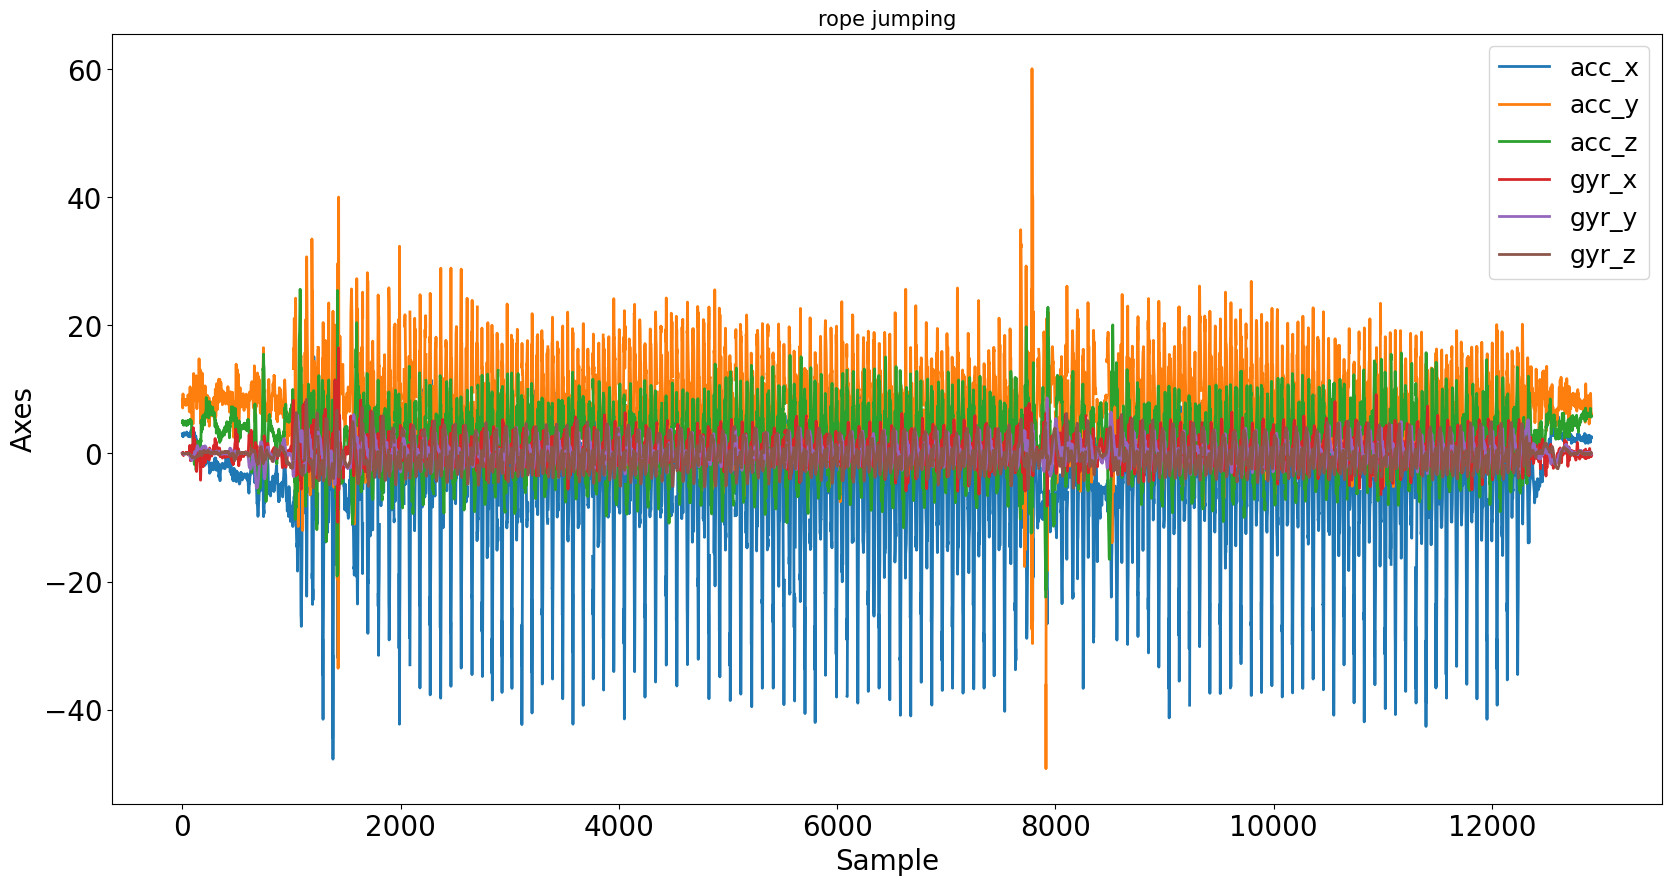

In [10]:
sample = df_segments[df_segments['activity_label'] == 'rope jumping'].iloc[0]

sample_signal_df = pd.DataFrame(dict(sample['data']))

plot_instance_time_domain(sample_signal_df)
plt.title(f"{sample['activity_label']}", fontsize=15)
plt.show()

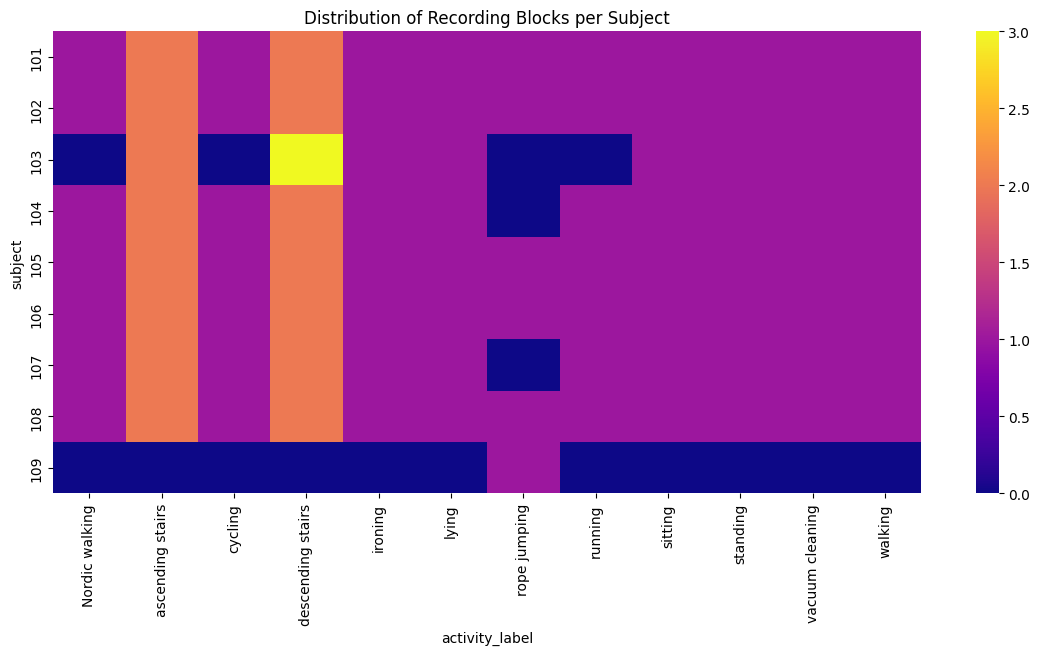

In [11]:
imbalance_matrix = pd.crosstab(df_segments['subject'], df_segments['activity_label'])

plot_heatmap(imbalance_matrix)
plt.title("Distribution of Recording Blocks per Subject")
plt.show()

## Data Processing

* Apply the sliding window algorithm to each segment (use `sliding_window_pd` from `utils.py` with the parameters defined in `config.yml`).
* Apply a low-pass Butterworth filter to each window (use `apply_filter` / `filter_instances` from `utils.py`).
* Detect outliers and confirm that no `NaN` values survive from the ingestion step.

Keep `(window, activity_label, subject)` triplets together throughout this section — you need the subject ID for the train/test split.

In [12]:
TRAIN_SUBJECTS = ["101", "102", "103", "104", "105", "107"]
TEST_SUBJECTS  = ["106", "108", "109"]

assert set(TRAIN_SUBJECTS).isdisjoint(TEST_SUBJECTS)

train_segments = df_segments[df_segments["subject"].astype(str).isin(TRAIN_SUBJECTS)]
test_segments  = df_segments[df_segments["subject"].astype(str).isin(TEST_SUBJECTS)]

from utils import make_pairs


training_windowpairs = make_pairs(train_segments,config)
test_windowpairs     = make_pairs(test_segments,config)



print(f"Train segments: {len(train_segments)}")
print(f"Test segments:  {len(test_segments)}")

print(f"Total window instances generated across training_subject segments: {len(training_windowpairs)}")
print(f"Total window instances generated across test_subject segments: {len(test_windowpairs)}")
print(f"Total window instances generated across both training and test segments: {len(training_windowpairs) + len(test_windowpairs)}")

Train segments: 79
Test segments:  29
Total window instances generated across training_subject segments: 4000
Total window instances generated across test_subject segments: 1379
Total window instances generated across both training and test segments: 5379


In [13]:
from utils import filter_pairs

filtered_training_list = filter_pairs(training_windowpairs, config)
filtered_test_list     = filter_pairs(test_windowpairs, config)

print(f"Filtered train windows : {len(filtered_training_list)}")
print(f"Filtered test windows  : {len(filtered_test_list)}")


Filtered train windows : 4000
Filtered test windows  : 1379


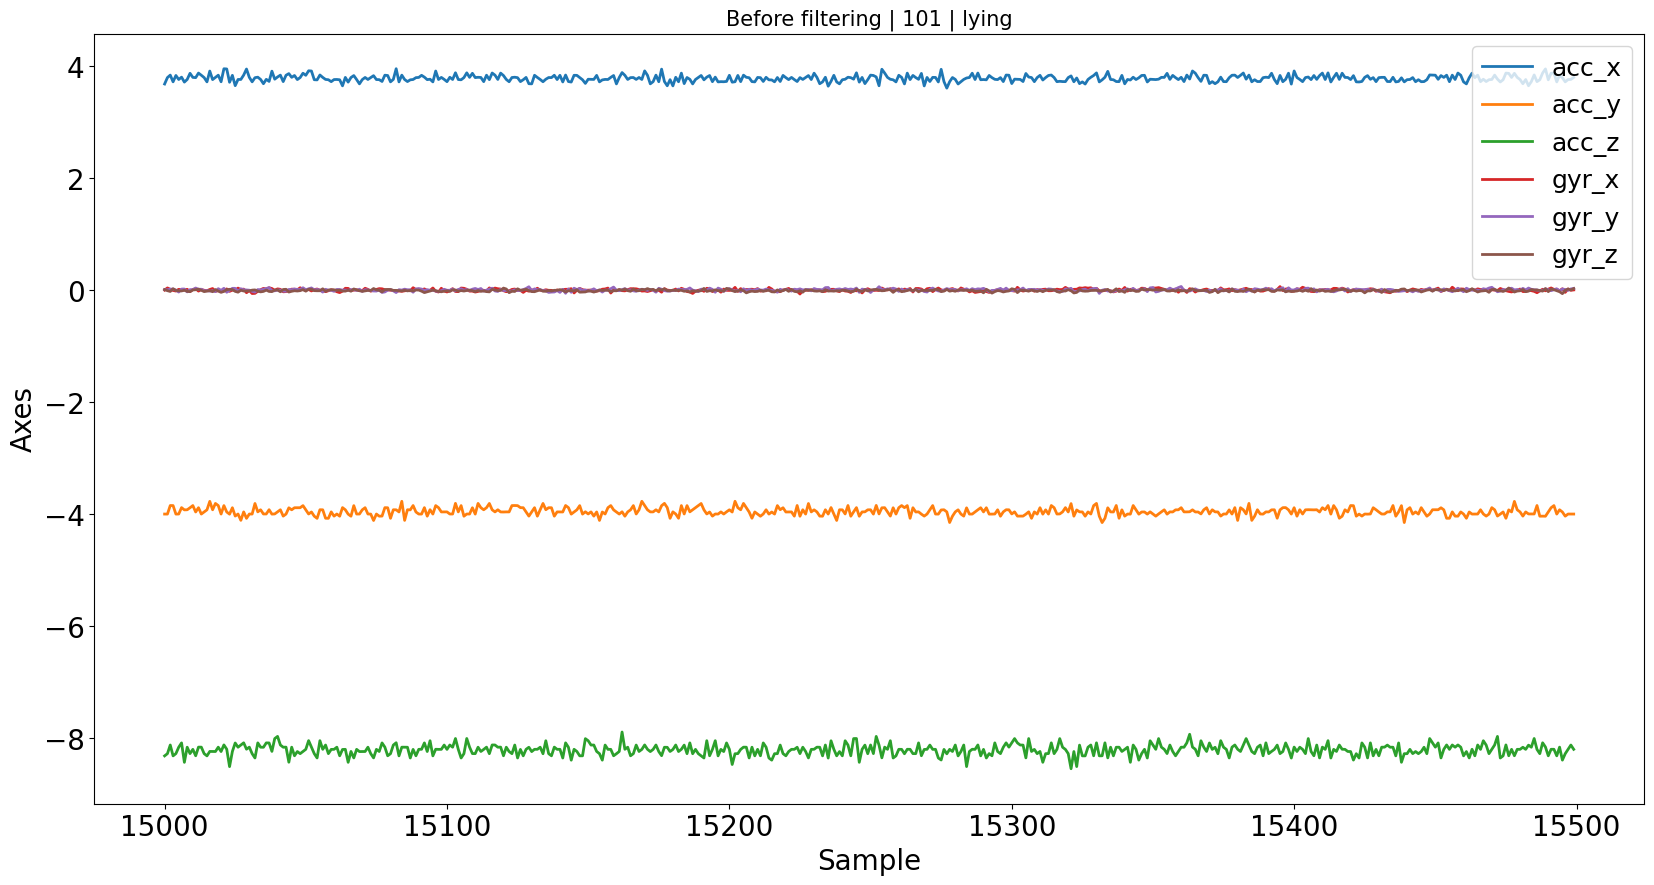

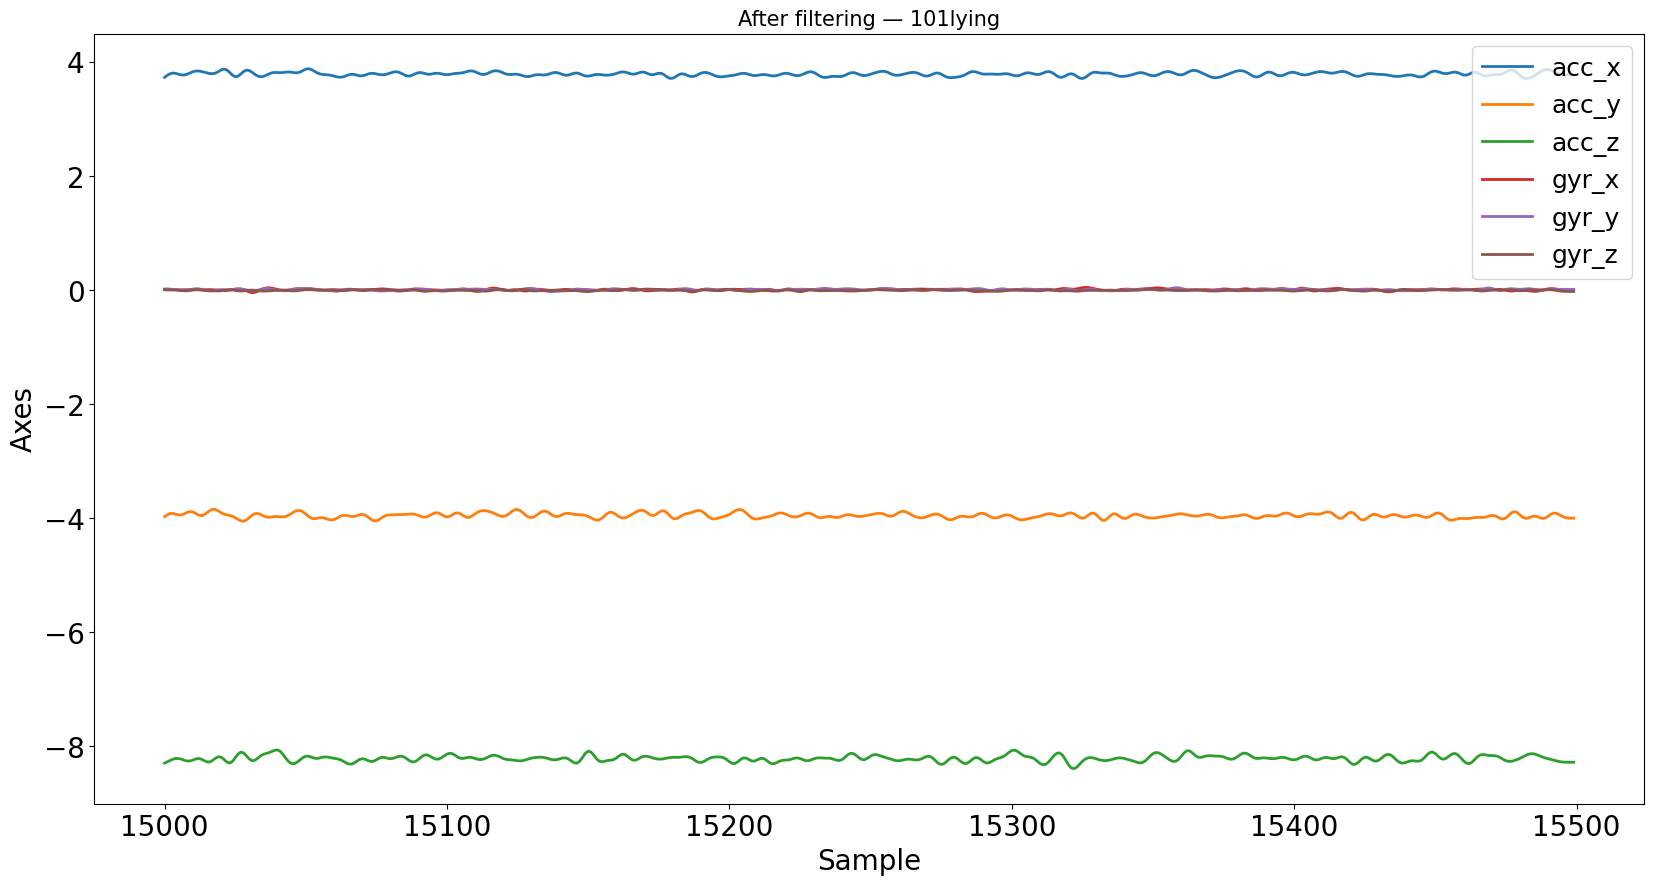

In [14]:
i = 60 # change to inspect different windows






# Before

plot_instance_time_domain(training_windowpairs[i]['window'])
plt.title(f"Before filtering | {training_windowpairs[i]['subject']} | {training_windowpairs[i]['activity_label']}", fontsize=15)
plt.show()

# After

plot_instance_time_domain(filtered_training_list[i])
plt.title(f"After filtering — {training_windowpairs[i]['subject']}{training_windowpairs[i]['activity_label']}", fontsize=15)
plt.show()



Activity: lying | Subject: 106


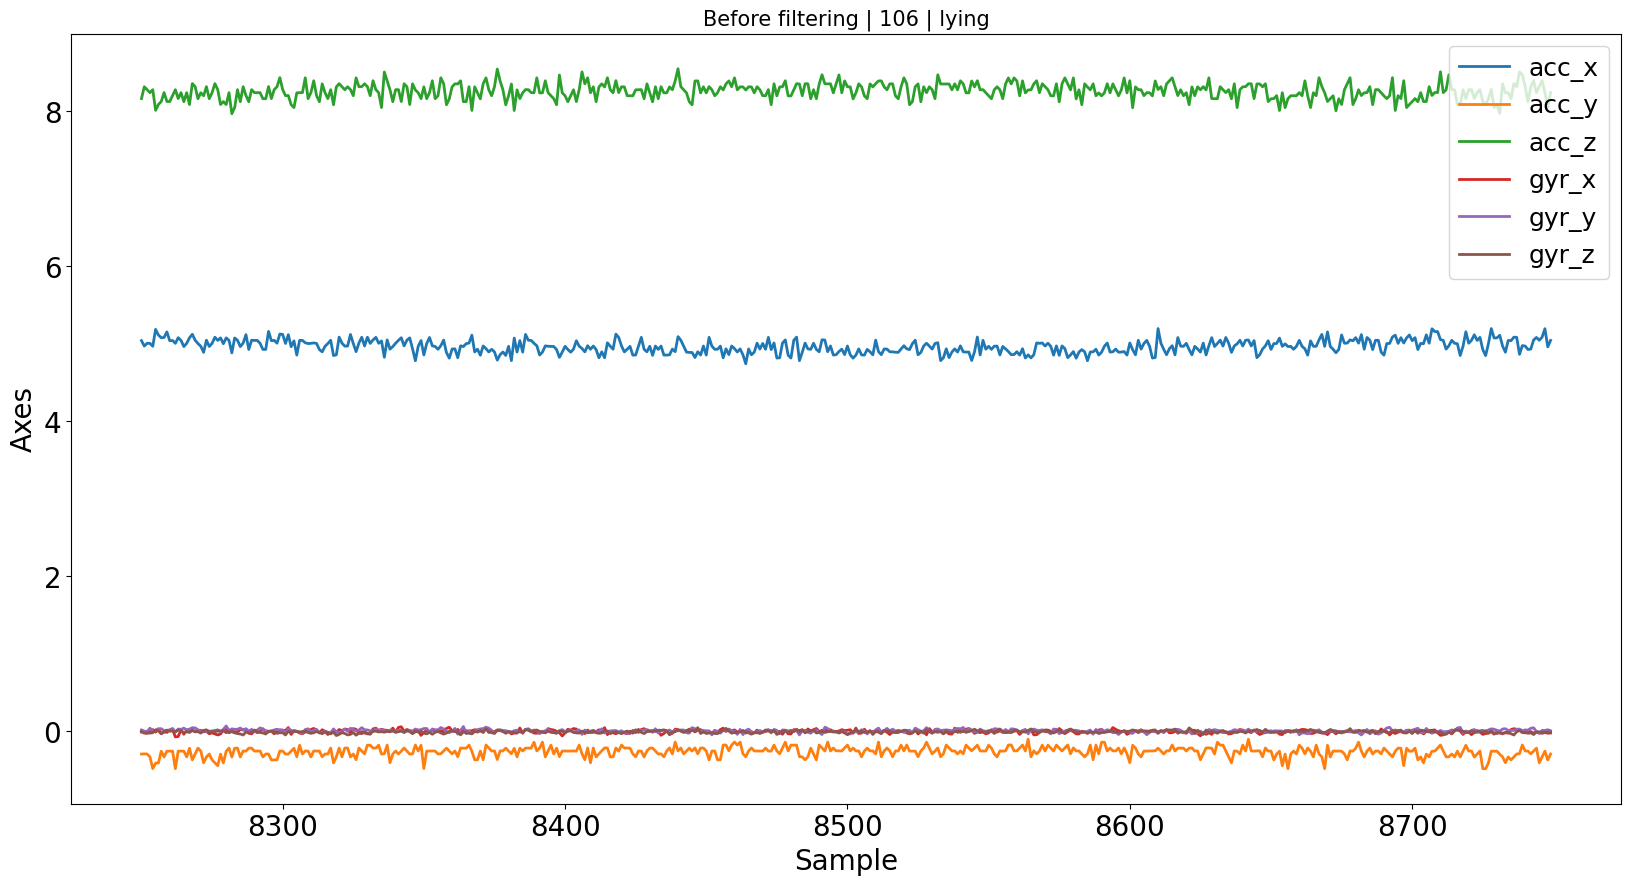

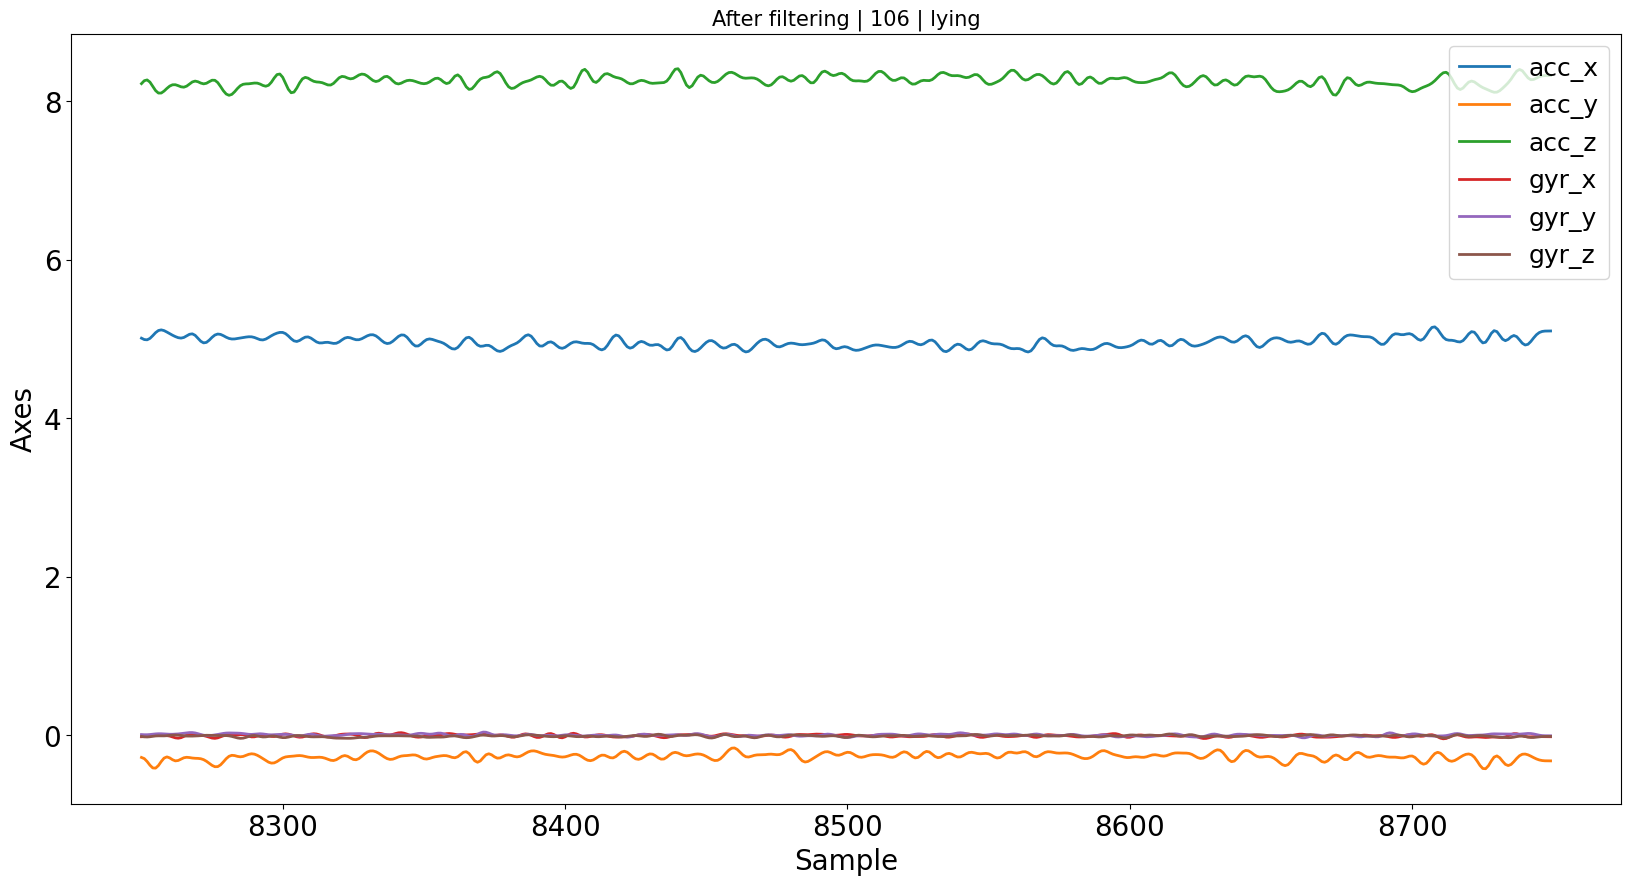

In [15]:
i = 30 # change to inspect different windows

print(f"Activity: {test_windowpairs[i]['activity_label']} | Subject: {test_windowpairs[i]['subject']}")




  # your window index



# Before

plot_instance_time_domain(test_windowpairs[i]['window'])
plt.title(f"Before filtering | {test_windowpairs[i]['subject']} | {test_windowpairs[i]['activity_label']}", fontsize=15)
plt.show()

# After

plot_instance_time_domain(filtered_test_list[i])
plt.title(f"After filtering | {test_windowpairs[i]['subject']} | {test_windowpairs[i]['activity_label']}", fontsize=15)
plt.show()



In [16]:
# ── NaN check after filtering ────────────────────────────────────────────────
nan_train = sum(df.isnull().values.any() for df in filtered_training_list)
nan_test  = sum(df.isnull().values.any() for df in filtered_test_list)

print(f"Train windows with NaN: {nan_train} / {len(filtered_training_list)}")
print(f"Test windows with NaN:  {nan_test}  / {len(filtered_test_list)}")

assert nan_train == 0, "NaN values found in training set!"
assert nan_test  == 0, "NaN values found in test set!"

print(" No NaN values found —")

Train windows with NaN: 0 / 4000
Test windows with NaN:  0  / 1379
 No NaN values found —


## Scaling

Fit the scaler on the training subjects only, then apply it to the test subjects.

In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from utils import flatten_instances_df, encode_labels

X_train = flatten_instances_df(filtered_training_list).to_numpy()
X_test  = flatten_instances_df(filtered_test_list).to_numpy()

y_train = encode_labels([p["activity_label"] for p in training_windowpairs])
y_test  = encode_labels([p["activity_label"] for p in test_windowpairs])

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

X_train: (4000, 3000) | y_train: (4000,)
X_test:  (1379, 3000)  | y_test:  (1379,)


## Classifier - Statistical Learning

### Apply simple classifier

In [18]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Get class names
le = LabelEncoder()
le.fit([p["activity_label"] for p in training_windowpairs])
class_names = le.classes_

#  Train SVM from config 
svm = SVC(
    C=config["classifier"]["SVC"]["C"],
    kernel=config["classifier"]["SVC"]["kernel"],
    gamma=config["classifier"]["SVC"]["gamma"],
)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# Train Random Forest from config
rf = RandomForestClassifier(
    n_estimators=config["classifier_2"]["RFC"]["n_estimators"],
    random_state=config["classifier_2"]["RFC"]["random_state"],
    n_jobs=config["classifier_2"]["RFC"]["n_jobs"]
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Reports 
print("=" * 50)
print("SVM"); print("=" * 50)
print(classification_report(y_test, y_pred_svm, target_names=class_names))

print("=" * 50)
print("Random Forest"); print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=class_names))



SVM
                   precision    recall  f1-score   support

   Nordic walking       1.00      0.51      0.68        88
 ascending stairs       0.59      0.84      0.69        92
          cycling       0.46      0.74      0.57       165
descending stairs       0.56      0.58      0.57        72
          ironing       0.57      0.30      0.40       228
            lying       0.78      0.96      0.86       179
     rope jumping       0.00      0.00      0.00        30
          running       0.27      0.60      0.38        25
          sitting       0.78      0.64      0.70       163
         standing       0.84      0.42      0.56       160
  vacuum cleaning       0.42      0.74      0.53       138
          walking       1.00      0.21      0.34        39

         accuracy                           0.60      1379
        macro avg       0.61      0.55      0.52      1379
     weighted avg       0.65      0.60      0.58      1379

Random Forest
                   precision    rec

c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

SVM Confusion Matrix


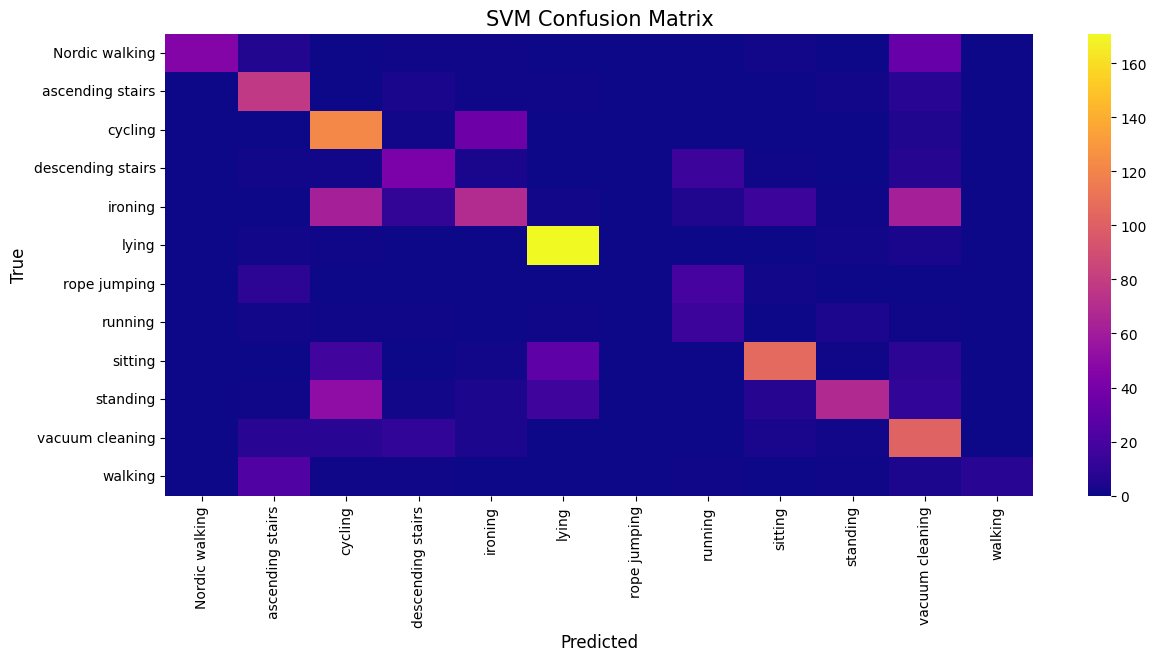

Random Forest Confusion Matrix


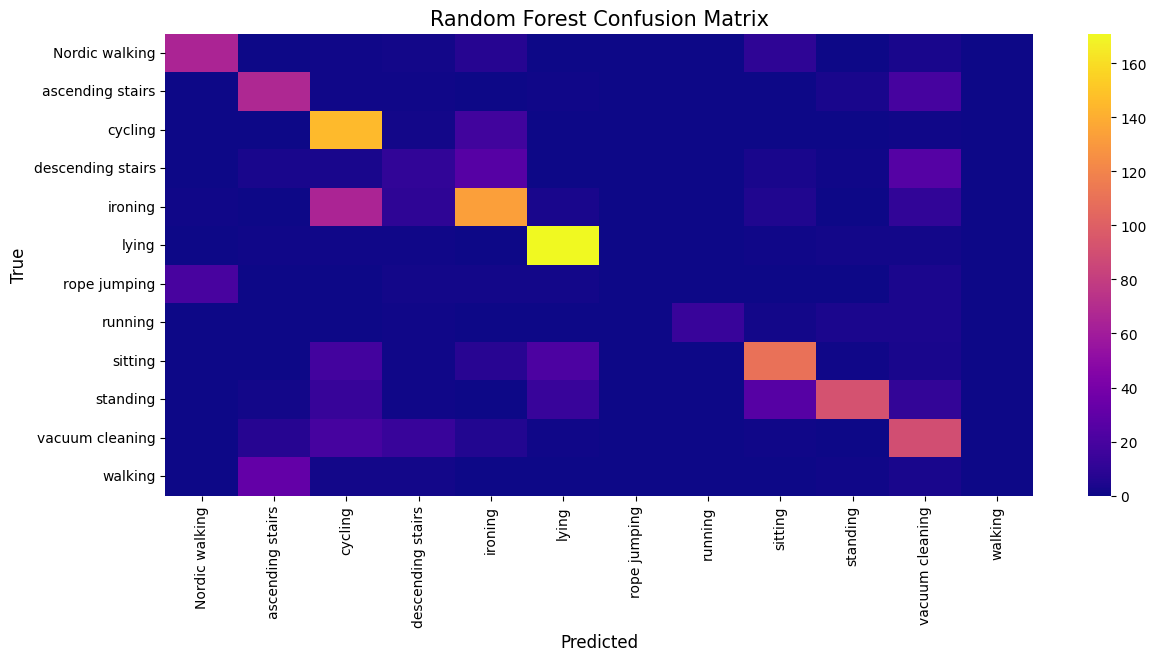

In [19]:
from utils_visual import plot_heatmap
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit([p["activity_label"] for p in training_windowpairs])
class_names = le.classes_

# SVM Confusion Matrix
cm_svm = pd.DataFrame(
    confusion_matrix(y_test, y_pred_svm),
    index=class_names,
    columns=class_names
)
print("SVM Confusion Matrix")
plot_heatmap(cm_svm)
plt.title("SVM Confusion Matrix", fontsize=15)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.show()

# Random Forest Confusion Matrix 
cm_rf = pd.DataFrame(
    confusion_matrix(y_test, y_pred_rf),
    index=class_names,
    columns=class_names
)
print("Random Forest Confusion Matrix")
plot_heatmap(cm_rf)
plt.title("Random Forest Confusion Matrix", fontsize=15)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.show()

### Evaluate simple classifier

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [21]:
from sklearn.metrics import classification_report
print("=" * 50)
print("SVM Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_svm, target_names=class_names))

print("=" * 50)
print("Random Forest Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=class_names))



SVM Classification Report
                   precision    recall  f1-score   support

   Nordic walking       1.00      0.51      0.68        88
 ascending stairs       0.59      0.84      0.69        92
          cycling       0.46      0.74      0.57       165
descending stairs       0.56      0.58      0.57        72
          ironing       0.57      0.30      0.40       228
            lying       0.78      0.96      0.86       179
     rope jumping       0.00      0.00      0.00        30
          running       0.27      0.60      0.38        25
          sitting       0.78      0.64      0.70       163
         standing       0.84      0.42      0.56       160
  vacuum cleaning       0.42      0.74      0.53       138
          walking       1.00      0.21      0.34        39

         accuracy                           0.60      1379
        macro avg       0.61      0.55      0.52      1379
     weighted avg       0.65      0.60      0.58      1379

Random Forest Classificatio

c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

### Apply optimization with Grid Search and/or Cross-validation

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters : {'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}
Best CV score   : 0.6425
                   precision    recall  f1-score   support

   Nordic walking       0.95      0.66      0.78        88
 ascending stairs       0.73      0.78      0.76        92
          cycling       0.53      0.80      0.63       165
descending stairs       0.50      0.74      0.60        72
          ironing       0.57      0.25      0.34       228
            lying       0.67      0.96      0.79       179
     rope jumping       1.00      0.03      0.06        30
          running       0.41      0.60      0.48        25
          sitting       0.65      0.71      0.68       163
         standing       0.80      0.50      0.62       160
  vacuum cleaning       0.50      0.59      0.54       138
          walking       0.82      0.59      0.69        39

         accuracy                           0.62      1379
        macro avg       

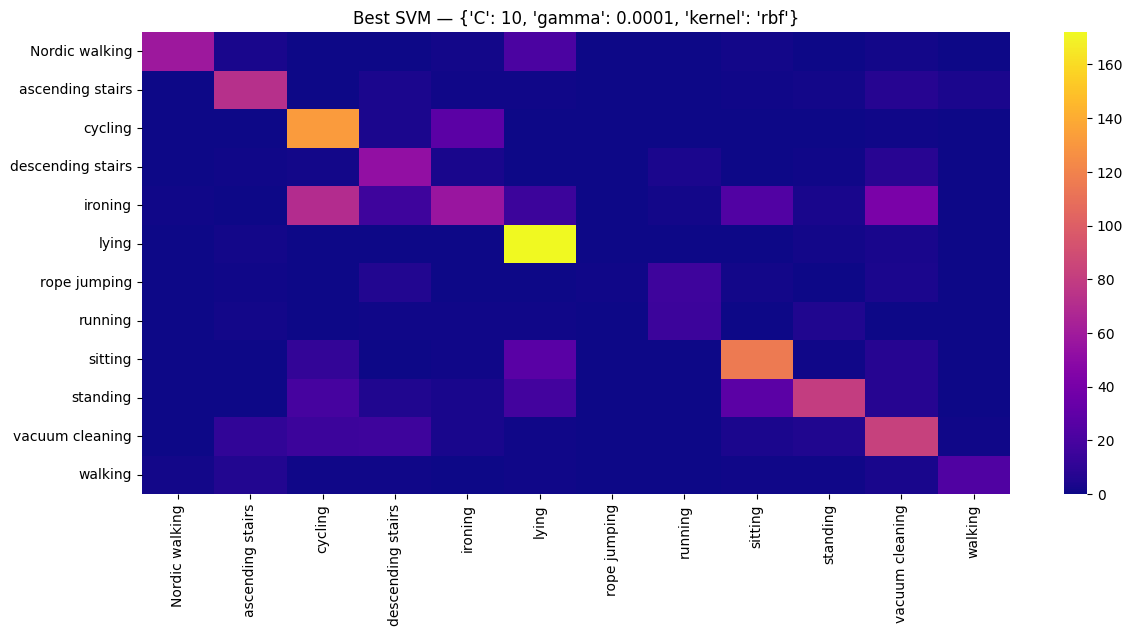

In [22]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=config["fine_tune"]["param_grid"],
    cv=config["fine_tune"]["cv"],
    verbose=config["fine_tune"]["verbose"],
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV score   : {grid_search.best_score_:.4f}")

y_pred_best = grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=class_names))

cm_best = pd.DataFrame(confusion_matrix(y_test, y_pred_best),
                       index=class_names, columns=class_names)
plot_heatmap(cm_best)
plt.title(f"Best SVM — {grid_search.best_params_}")
plt.show()

### Evaluate optimized classifier

Once you are satisfied with the wrist-only configuration, repeat the **load → process → train → evaluate** flow for the chest and ankle IMUs (and combinations thereof) and compare the metrics in your report.